In [22]:
from dotenv import load_dotenv
load_dotenv()

True

In [23]:
from langchain_openai import ChatOpenAI
llm=ChatOpenAI(model="gpt-4o")


In [24]:
def add(a: int , b:int):
     """ Add a and b
    Args:
        a (int): first int
        b (int): second int

     Returns:
        int
     """
     return a+b

In [25]:
from langchain_core.messages import HumanMessage

llm_with_tool=llm.bind_tools([add])
llm_with_tool.invoke([HumanMessage(content=f"What is 2 plus 2", name="Ahad")])
# llm_with_tool

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 77, 'total_tokens': 94, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_d9a8f17212', 'id': 'chatcmpl-DdCZKMvchPaBJDBOg22jaOCbq42MK', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e0718-0814-7743-8504-81c4443d4cbb-0', tool_calls=[{'name': 'add', 'args': {'a': 2, 'b': 2}, 'id': 'call_OIXysmCiEzbXMefiXiqnN3xO', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 17, 'total_tokens': 94, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

### Using message as a state

In [39]:
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from typing import Annotated
from langchain_core.messages import AnyMessage

class State(TypedDict):
    messages:Annotated[list[AnyMessage], add_messages]

In [ ]:
from langchain_core.messages import AIMessage , HumanMessage
from pprint import pprint

messages=[AIMessage(content=f"Please tell me how can I help",name="LLMModel")]
messages.append(HumanMessage(content=f"I want to learn coding",name="Ahad"))
messages.append(AIMessage(content=f"Which programming language you want to learn",name="LLMModel"))
messages.append(HumanMessage(content=f"I want to learn python programming language",name="Ahad"))

for message in messages:
    message.pretty_print()

In [17]:

## chatbot node functionality
def llm_tool(State):
    return {"messages":[llm_with_tool.invoke(State["messages"])]}

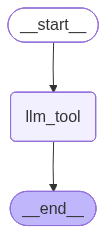

In [29]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

builder=StateGraph(State)

builder.add_node("llm_tool",llm_tool)

builder.add_edge(START,"llm_tool")
builder.add_edge("llm_tool",END)

graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:


messages = graph.invoke({"messages": "What is 2 plus 2"})

for message in messages["messages"]:
   message.pretty_print()

In [49]:

tools= [add]

In [50]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


builder=StateGraph(State)
## Add nodes

builder.add_node("llm_tool",llm_tool)
builder.add_node("tools",ToolNode(tools))

## Add Edge
builder.add_edge(START,"llm_tool")
builder.add_conditional_edges(
    "llm_tool",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)


graph_builder = builder.compile()



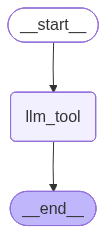

In [51]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [45]:
## invocation

messages=graph.invoke({"messages":"What is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================

2 plus 2 equals 4.
